# Introduction


**In this lecture, we will learn**
- what a geometric transformation is,
- what types of transformations there are,
- how estimate a geometric transformation between two sets of correspondences,
- and what a pixel interpolation is.

**The lecture is based on**
- Chapter 21 "Geometric Operations" of  
  [\[Burger22\] Wilhelm Burger, Mark J. Burge: "Digital Image Processing: An Algorithmic Introduction (3rd edition)"](https://imagingbook.com/books/english-edition-hardcover/)

In [1]:
from typing import Literal

import cv2 as cv
import ipywidgets
import matplotlib.pyplot as plt
import numpy as np
import skimage

In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
np.set_printoptions(threshold=20, edgeitems=10, linewidth=140, precision=6, suppress=True)

In [3]:
def imshow_grid(
    nrows: int | None = None,
    ncols: int | None = None,
    cmap: str = 'gray',
    vmin: int | float | Literal['min'] = 0,
    vmax: int | float | Literal['dtype', 'max'] = 'dtype',
    grid: bool = False,
    colorbar: bool = True,
    interpolation: Literal['nearest', 'bilinear'] = 'nearest',
    **images,
):
    if nrows is None:
        nrows = 1
    if ncols is None:
        ncols = -int(-len(images) // nrows)  # ceil
    fig_size_y = nrows * plt.rcParams['figure.figsize'][1]
    fig_size_x = max(1, ncols / 2) * plt.rcParams['figure.figsize'][0]
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_size_x, fig_size_y), layout='constrained')
    axes = np.atleast_1d(axes)
    im = None
    for ax, (name, img) in zip(axes.flat, images.items()):
        _vmin = vmin
        if _vmin == 'min':
            _vmin = img.min()
        _vmax = vmax
        if _vmax == 'dtype':
            _vmax = np.iinfo(img.dtype).max if np.issubdtype(img.dtype, np.integer) else 1.0
        elif _vmax == 'max':
            _vmax = img.max()
        im = ax.imshow(img, cmap=cmap, vmin=_vmin, vmax=_vmax, interpolation=interpolation)
        ax.grid(grid)
        ax.set_title(name)
    if colorbar and im is not None:
        if ncols > nrows:
            orientation = 'horizontal'
        elif ncols == nrows:
            orientation = 'horizontal' if im.get_size()[1] > im.get_size()[0] else 'vertical'
        else:
            orientation = 'vertical'
        if vmin == 'min' or vmax == 'max':
            for ax in axes.flat[:len(images)]:
                fig.colorbar(ax.images[0], ax=ax, orientation=orientation, aspect=30)
        else:
            fig.colorbar(im, ax=axes, orientation=orientation, aspect=50)
    return fig, axes

# Geometric transformations

<figure class="image">
  <img src="../figures/geometric_transformations-examples.png" alt="" style="width: 12.8in;"/>
  <figcaption>Source: [Burger22], Fig. 21.1</figcaption>
</figure>

- In previous lectures, we saw intensity transformations and spatial and frequency filters may significantly alter the image appearance, but their ability to change shapes and/or spatial relationships between objects is very limited.
- In other words, they modify texture but not shape.
- Geometric transformations target the opposite effect: change shape without altering the texture.
- Intuitively, instead of tinkering with pixel intensities, we're going to move the pixels around the image.
- Formally, positions of pixels are going to change according to
  $$
  x' = T_x(x, y) \\
  y' = T_y(x, y)
  $$
  where
  - $(x, y)$ is the original pixel's position,
  - $(x', y')$ is the new transformed position,
- We'll create the new transformed image $I'$ by copying the every pixel from its old position to the new one, i.e.
  $$
  I(x, y) \rightarrow I'(x', y')
  $$

## Simple example: shift (translate) the image by some offset

- Let's try to translate the entire image by some offset, like in the (b) case of the figure above.
- We're going to shift every pixel by the same amount, i.e.
  $$
  x' = x + t_x \\
  y' = y + t_y
  $$
  where
  - $(x, y)$ is the original pixel's position,
  - $(t_x, t_y)$ are the offsets in $x$ and $y$ directions, respectively,
  - $(x', y'$ is the new pixel's position.

In [4]:
def shift_fw(img: np.ndarray, tx: float = 0.0, ty: float = 0.0) -> np.ndarray:
    # Initialize the new image with zeros (black)
    img_ = np.zeros_like(img)

    # Iterate over all pixels in the original image and place them in the new image at the shifted coordinates
    h, w = img.shape[:2]
    for y in range(h):
        for x in range(w):
            # Compute new coordinates according to the equations; don't forget to convert them to integers
            x_ = int(0.5 + x + tx)
            y_ = int(0.5 + y + ty)
            # Check if the new coordinates are within the image bounds
            if 0 <= x_ < w and 0 <= y_ < h:
                # If yes, then simply copy the pixel value to the new location
                img_[y_, x_] = img[y, x]
    return img_

In [5]:
rgb = skimage.io.imread('../data/robot.png')
rgb.shape, rgb.dtype, rgb.min(), rgb.max()

((234, 160, 3), dtype('uint8'), np.uint8(0), np.uint8(255))

In [6]:
gray = skimage.color.rgb2gray(rgb)
gray.shape, gray.dtype, gray.min(), gray.max()

((234, 160), dtype('float64'), np.float64(0.0), np.float64(1.0))

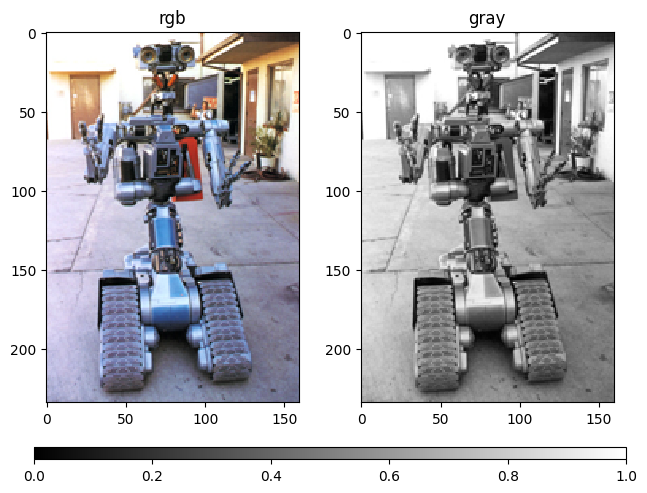

In [7]:
imshow_grid(rgb=rgb, gray=gray);

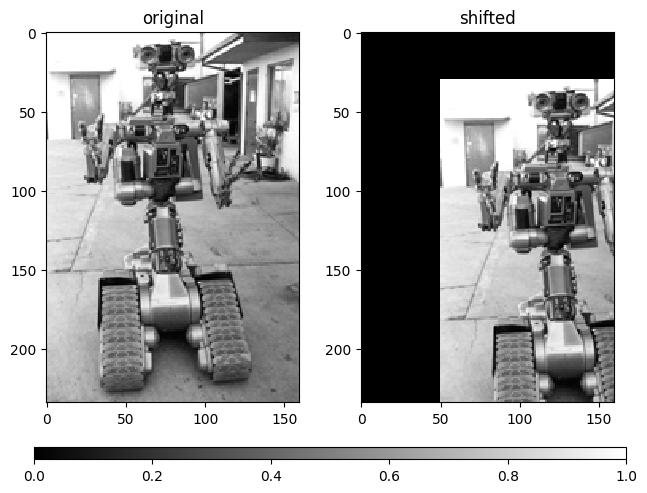

In [8]:
gray_transl = shift_fw(gray, tx=50, ty=30)
imshow_grid(original=gray, shifted=gray_transl);

### Size of the output

- We see that in order for the shifted image to be fully contained in the frame (not cropped), the output image must be larger than the input.
- We will add an parameter to the `shift_fw` function to allow us to specify custom output size.

In [9]:
def shift_fw(
    img: np.ndarray,
    tx: float = 0.0,
    ty: float = 0.0,
    out_shape: tuple[int, int] | None = None,
) -> np.ndarray:
    # Input size
    h, w = img.shape[:2]

    # Output size
    if out_shape is None:
        # If we want the same size as input
        h_, w_ = h, w
    else:
        # If we want a custom size
        h_, w_ = out_shape

    # Initialize the new image with zeros (black)
    img_ = np.zeros((h_, w_), dtype=img.dtype)

    # Iterate over all pixels in the original image and place them in the new image at the shifted coordinates
    for y in range(h):
        for x in range(w):
            # Compute new coordinates according to the equations; don't forget to convert them to integers
            x_ = int(0.5 + x + tx)
            y_ = int(0.5 + y + ty)
            # Check if the new coordinates are within the *output* image bounds
            if 0 <= x_ < w_ and 0 <= y_ < h_:
                # If yes, then simply copy the pixel value to the new location
                img_[y_, x_] = img[y, x]
    return img_

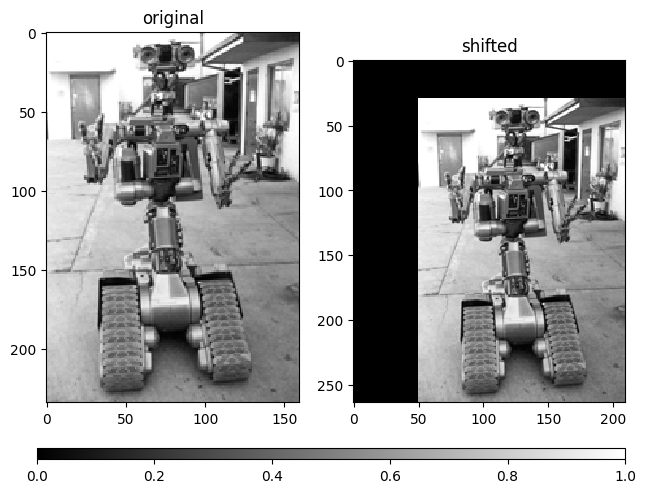

In [10]:
gray_transl = shift_fw(gray, tx=50, ty=30, out_shape=(gray.shape[0]+30, gray.shape[1]+50))
imshow_grid(original=gray, shifted=gray_transl);

## Simple example: scaling

- Let's try another simple transformation: scaling (case (c) in the figure above).
- The rule for moving pixels is
  $$
  x' = s_x \cdot x \\
  y' = s_y \cdot y
  $$

In [11]:
def scale_fw(img: np.ndarray, sx: float = 1.0, sy: float = 1.0, out_shape: tuple[int, int] | None = None) -> np.ndarray:
    h, w = img.shape[:2]
    if out_shape is None:
        h_, w_ = h, w
    else:
        h_, w_ = out_shape
    img_ = np.zeros((h_, w_), dtype=img.dtype)
    for y in range(h):
        for x in range(w):
            # Here is the change: scale instead of shift
            x_ = int(0.5 + x * sx)
            y_ = int(0.5 + y * sy)
            if 0 <= x_ < w_ and 0 <= y_ < h_:
                img_[y_, x_] = img[y, x]
    return img_

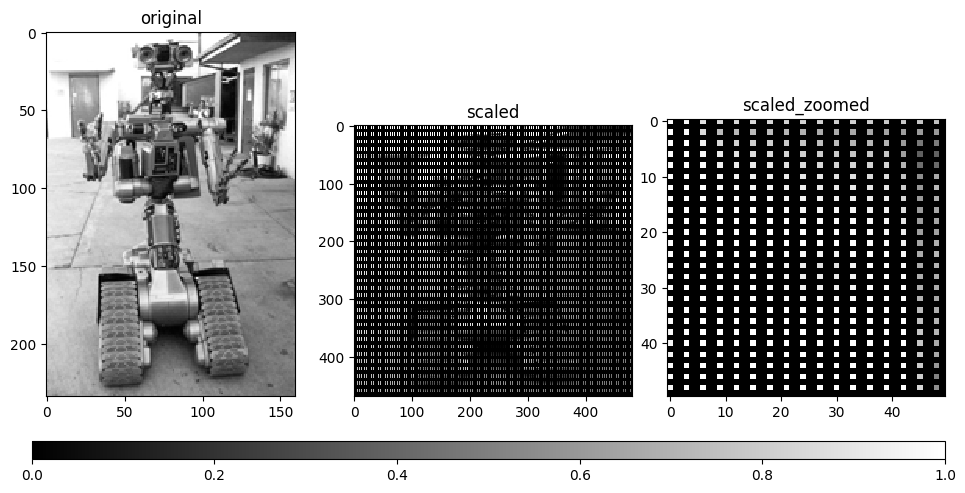

In [12]:
gray_scl = scale_fw(gray, sx=3.0, sy=2.0, out_shape=(gray.shape[0]*2, gray.shape[1]*3))
imshow_grid(original=gray, scaled=gray_scl, scaled_zoomed=gray_scl[50:100, :50]);

### What happened? Toy example to illustrate the problem

- We can see that the output image has lots of "holes" in it.
- This is not that surprising given the fact we're simply moving constant number of pixels from the input image to the output one *irrespective of the applied scale*, even though it is obvious that when using scales > 1, the output image will have many more pixels than the input image.
- Since we first initialized the output to zeros and then only filled those positions in which we "landed" after scaling each input position, we effectively ignored most parts of the output.

In [13]:
toy_gray = 1 + np.arange(6).reshape((2, 3))
toy_gray

array([[1, 2, 3],
       [4, 5, 6]])

In [14]:
scale_fw(toy_gray, sx=3.0, sy=2.0, out_shape=(4, 9))

array([[1, 0, 0, 2, 0, 0, 3, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0],
       [4, 0, 0, 5, 0, 0, 6, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], shape=(4, 9))

## Resampling the image

- One problem of the above approach is when the output has more pixels than the input, it will have "holes".
- If it has *fewer* pixels, the function will in turn write to some locations multiple times, leading to inefficiency.
- Both problems can be solved by realizing that we need to compute the value and position of each and every pixel of the *output*, not of the input.
- So instead of
  - iterating over the input pixels and moving them from the input to the output,  
  - we can iterate over the *output* pixels, calculate their corresponding input positions using *inverse mapping*, and copy the value from there.
- That way
  - no output pixel is left unvisited (with the default initialized value),
  - and each output value is computed exactly once.
- The whole problem is an example of coordinate mapping between the original image (source) and the transformed one (target).

<figure class="image">
  <img src="../figures/geometric_transformations-forward_inverse_mappings.png" alt="" style="width: 12.8in;"/>
  <figcaption>Source: [Burger22], Fig. 21.14 and 21.15</figcaption>
</figure>

**1. Forward mapping (source-to-target)**
- This is what we used above e.g. in the `scale_fw` function.
- Method:
  1. Iterate over each *input* position $(x, y)$,
  2. Calculate the *output* coordinate as $(x', y') = T(x, y)$,
  3. Copy the pixel value as $I(x', y') = I(x, y)$.
- Written in short
  $$
  I'(T(\bold{x})) = I(\bold{x})
  $$
  where
  - $I$ is the image function,
  - $\bold{x} = (x, y)$ are pixel coordinates,
  - $T: \mathbb{R}^2 \rightarrow \mathbb{R}^2$ is a geometric mapping.

**2. Inverse mapping (target-to-source)**
- This is what we're going to implement next.
- Method:
  1. Iterate over each *output* position $(x', y')$
  2. Calculate corresponding *input* position as $(x, y) = T^{-1}(x', y')$,
  3. Copy the pixel value as $I'(x', y') = I(x, y)$.
- Written in short
  $$
  I'(\bold{x}') = I(T^{-1}(\bold{x}'))
  $$
  where
  - $\bold{x}' = (x', y') = T(\bold{x})$

**Forward vs inverse mapping**
- The *inverse* mapping better suited for implementation of the transformations, because it solves the problems encountered above with the forward mapping.
- The *forward* mapping is still useful for formulating and understanding the transformations.

## Example: scaling via inverse mapping

- The *forward mapping* of scaling is  
  $$
  x' = s_x \cdot x \\
  y' = s_y \cdot y
  $$
- The *inverse mapping* of scaling is
  $$
  x = s_x^{-1} \cdot x' \\
  y = s_y^{-1} \cdot y'
  $$

In [15]:
def scale_inv(
    img: np.ndarray,
    sx: float = 1.0,
    sy: float = 1.0,
    out_shape: tuple[int, int] | None = None,
) -> np.ndarray:
    h, w = img.shape[:2]
    if out_shape is None:
        h_, w_ = h, w
    else:
        h_, w_ = out_shape
    img_ = np.zeros((h_, w_), dtype=img.dtype)
    # Now iterate over *output* coordinates instead of input
    for y_ in range(h_):
        for x_ in range(w_):
            # Compute the corresponding input position (x, y) using *inverse* mapping
            x = int(0.5 + x_ / sx)  # Note the division instead of multiplication here
            y = int(0.5 + y_ / sy)  # ...
            if 0 <= x < w and 0 <= y < h:
                img_[y_, x_] = img[y, x]
    return img_

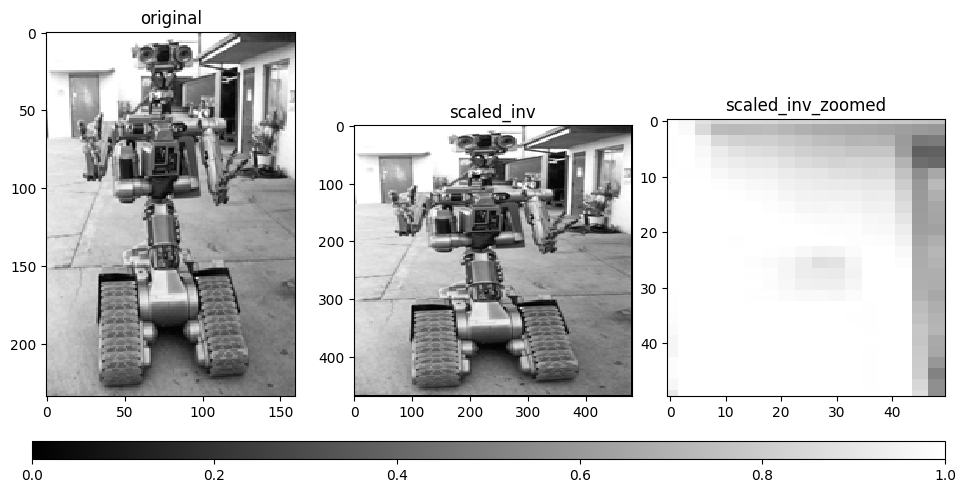

In [16]:
gray_scl = scale_inv(gray, sx=3.0, sy=2.0, out_shape=(gray.shape[0]*2, gray.shape[1]*3))
imshow_grid(original=gray, scaled_inv=gray_scl, scaled_inv_zoomed=gray_scl[50:100, :50]);

## Example: horizontal skewing (shearing) via inverse mapping

- The *forward mapping* of horizotnal skewing (shearing) by angle $\phi$ is  
  $$
  x' = x + y \cdot \tan \Phi \\
  y' = y
  $$
- The *inverse mapping* is
  $$
  x = x' - y \cdot \tan \Phi \\
  y = y'
  $$

In [17]:
def skew_inv(
    img: np.ndarray,
    phi: float = 0.0,
    out_shape: tuple[int, int] | None = None,
) -> np.ndarray:
    h, w = img.shape[:2]
    if out_shape is None:
        h_, w_ = h, w
    else:
        h_, w_ = out_shape
    img_ = np.zeros((h_, w_), dtype=img.dtype)
    # Now iterate over *output* coordinates instead of input
    for y_ in range(h_):
        for x_ in range(w_):
            # Compute the corresponding input position (x, y) using *inverse* mapping
            y = int(0.5 + y_)
            x = int(0.5 + x_ - y * np.tan(phi))
            if 0 <= x < w and 0 <= y < h:
                img_[y_, x_] = img[y, x]
    return img_

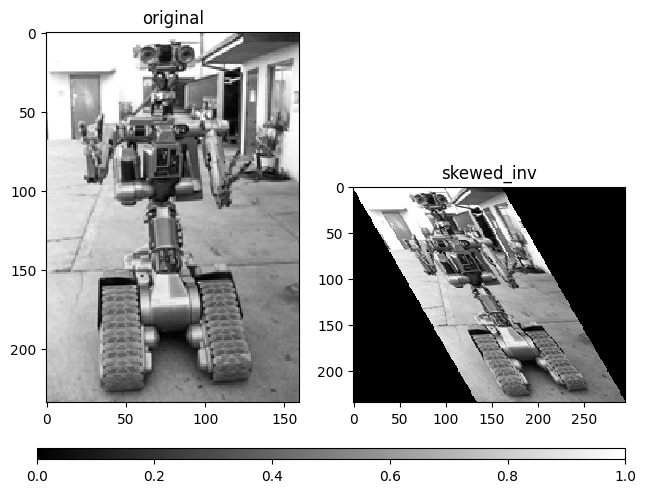

In [18]:
phi_skw = np.pi / 6  # 30 degrees
gray_skw = skew_inv(gray, phi=phi_skw, out_shape=(gray.shape[0], gray.shape[1]+int(gray.shape[0]*abs(np.tan(phi_skw)))))
imshow_grid(original=gray, skewed_inv=gray_skw);

# Matrix form and homogenous coordinates

- The transformations above all have the **affine** form  
  $$
  x' = a_{1,1} \cdot x + a_{1,2} \cdot y + a_{1,3} \\
  y' = a_{2,1} \cdot x + a_{2,2} \cdot y + a_{2,3}
  $$
  where $a_{i,j} \in \mathbb{R}$
- This can be written as a matrix-vector multiplication  
  $$
  \underbrace{
    \begin{bmatrix}
    x' \\
    y' \\
    1
    \end{bmatrix}
  }_{\bold{x}'}
  =
  \underbrace{
    \begin{bmatrix}
    a_{1,1} & a_{1,2} & a_{1,3} \\
    a_{2,1} & a_{2,2} & a_{2,3} \\
    0 & 0 & 1
    \end{bmatrix}
  }_{\bold{A}}
  \cdot
  \underbrace{
    \begin{bmatrix}
    x \\
    y \\
    1
    \end{bmatrix}
  }_{\bold{x}}
  $$
  or for short  
  $$
  \bold{x}' = \bold{A}\cdot\bold{x}
  $$
- You may notice that instead of a pair of cartesian $(x, y)$ coordinates, we express each position in an image as a *triplet* of **homogenous coordinates** $(x, y, 1)$ by appending 1 to the original pair.
  $$
  \begin{bmatrix}
  x \\
  y
  \end{bmatrix}
  \rightarrow
  \begin{bmatrix}
  x \\
  y \\
  1
  \end{bmatrix}
  $$
- Notice that for any affine transformation the last element of $\bold{x}'$ will always remain 1.
- Why would we bother? There are two main reasons:
  1. linearity of matrix-vector multiplication will allow us **concatenate** geometric transformations,
  2. matrix form allows for straightforward transformation **inversion** using linear algebra instead of manual calculation.

**Affine matrix concatenation**
- Using the matrix form, we can concatenate as simple matrix-matrix multiplication, i.e.  
  $$
  \bold{C} = \bold{A} \cdot \bold{B}
  $$
  where
  - $\bold{A}$, $\bold{B}$ are matrices of the concatenated transformations,
  - $\bold{C}$ is the resulting transformation
- It can be seen that when both $\bold{A}$ and $\bold{B}$ are affine, the result is also affine.

**Affine matrix inversion**
- For any non-singular *affine* matrix $\bold{A}$ whose last row is $[0,0,1]$ as defined above, the inverse is  
  $$
  \bold{A}^{-1} = \frac{1}{\det\bold{A}}\begin{bmatrix}
   a_{2,2} & -a_{1,2} & a_{1,2} \cdot a_{2,3} - a_{1,3} \cdot a_{2,2} \\
  -a_{2,1} &  a_{1,1} & a_{1,1} \cdot a_{2,3} - a_{1,3} \cdot a_{2,1} \\
  0       & 0        & 1 \\
  \end{bmatrix}
  $$
  where
  - $\det{\bold{A}} = a_{1,1} \cdot a_{2, 2} - a_{1,2} \cdot a_{2,1}$ is the determinant of $\bold{A}$
- This means that inverse of any affine transformation is also affine and that when computing  
  $$
  \begin{bmatrix}
  x \\
  y \\
  1
  \end{bmatrix}
  =
  \bold{A}^{-1}
  \cdot
  \begin{bmatrix}
  x' \\
  y' \\
  1
  \end{bmatrix}
  $$
  the last element of $\bold{x} = [x, y, 1]^\top$ is always guaranteed to be 1.

## General function for affine transformations

- Combining the two ideas above (inverse mapping and matrix form), we'll now construct a general `warp_affine_inv` function.
- The inputs are
  - the image to be transformed,
  - 3x3 affine matrix representing the transformation.
- But first we'll also need an auxilliary function that will simplify computation of the output shape `out_shape`.
- Most of the time, we want the transformed image to be fully contained in the output.
- Since we now don't know the precise form of the transformation, only its matrix, we'll compute the output size as
  1. transform the input image's corners
  2. compute a bounding box of the trasnformed corners.

In [19]:
def calc_out_shape_affine(img: np.ndarray, A: np.ndarray) -> tuple[int, int]:
    h, w = img.shape[:2]

    # Get image corners and transform them
    X = np.array([0., w, w, 0.])
    Y = np.array([0., 0., h, h])
    XY = np.vstack((X, Y, np.ones(4)))
    XY_ = np.dot(A, XY)
    
    # Calculate the new size
    w_ = int(XY_[0, :].max() - XY_[0, :].min())
    h_ = int(XY_[1, :].max() - XY_[1, :].min())
    
    return h_, w_

In [20]:
def warp_affine_inv(img: np.ndarray, A: np.ndarray, out_shape: tuple[int, int] | None = None) -> np.ndarray:
    # Input shape
    h, w = img.shape[:2]

    # Output shape
    if out_shape is None:
        h_, w_ = h, w
    else:
        h_, w_ = out_shape
    if img.ndim == 2:
        img_ = np.zeros((h_, w_), dtype=img.dtype)
    else:
        img_ = np.zeros((h_, w_, img.shape[2]), dtype=img.dtype)
    
    # Invert transformation
    A_inv = np.linalg.inv(A)

    # Helper function to safely get a value gray[y, x]
    def src_img_at(x, y):
        if 0 <= x < w and 0 <= y < h:
            return img[y, x]
        else:
            return 0

    # The main transformation loop
    for y_ in range(h_):
        for x_ in range(w_):
            x, y, z = np.dot(A_inv, [x_, y_, 1.0])  # inverse transform
            assert z == 1.0, 'A is not affine'  # check if A is affine
            x = int(0.5 + x)  # round
            y = int(0.5 + y)  # round
            img_[y_, x_] = src_img_at(x, y)  # src_img_at defined on line 16 of this function
    
    return img_

### Example: scaling via matrix form

In [21]:
sx, sy = 3.0, 2.0
A_scl = np.array([
    [sx, 0., 0.],
    [0., sy, 0.],
    [0., 0., 1.],
])
A_scl, np.linalg.inv(A_scl)

(array([[3., 0., 0.],
        [0., 2., 0.],
        [0., 0., 1.]]),
 array([[0.333333, 0.      , 0.      ],
        [0.      , 0.5     , 0.      ],
        [0.      , 0.      , 1.      ]]))

In [22]:
gray_scl = warp_affine_inv(gray, A_scl, out_shape=calc_out_shape_affine(gray, A_scl))
gray_scl.shape, gray_scl.dtype

((468, 480), dtype('float64'))

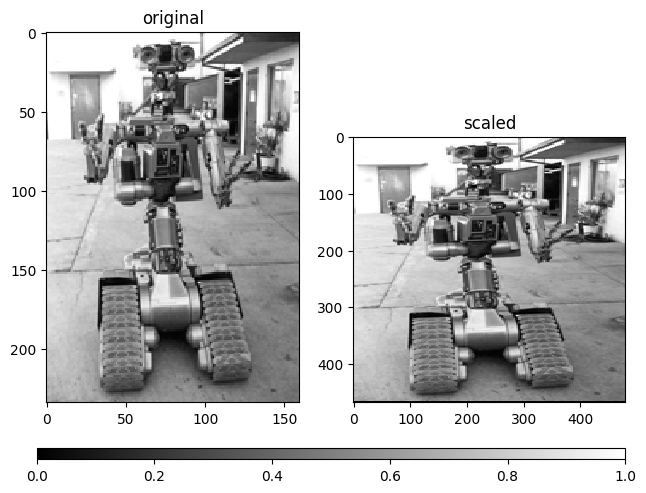

In [23]:
imshow_grid(original=gray, scaled=gray_scl);

### Example: skewing via matrix form

In [24]:
phi_skw = -15. / 180. * np.pi
A_skw = np.array([
    [1., np.tan(phi_skw), abs(gray.shape[0] * np.tan(phi_skw)) if phi_skw < 0 else 0.],  # also add offset to keep image in frame
    [0., 1., 0.],
    [0., 0., 1.],
])
A_skw, np.linalg.inv(A_skw)

(array([[ 1.      , -0.267949, 62.700111],
        [ 0.      ,  1.      ,  0.      ],
        [ 0.      ,  0.      ,  1.      ]]),
 array([[  1.      ,   0.267949, -62.700111],
        [  0.      ,   1.      ,   0.      ],
        [  0.      ,   0.      ,   1.      ]]))

In [25]:
gray_skw = warp_affine_inv(gray, A_skw, out_shape=calc_out_shape_affine(gray, A_skw))
gray_skw.shape, gray_skw.dtype

((234, 222), dtype('float64'))

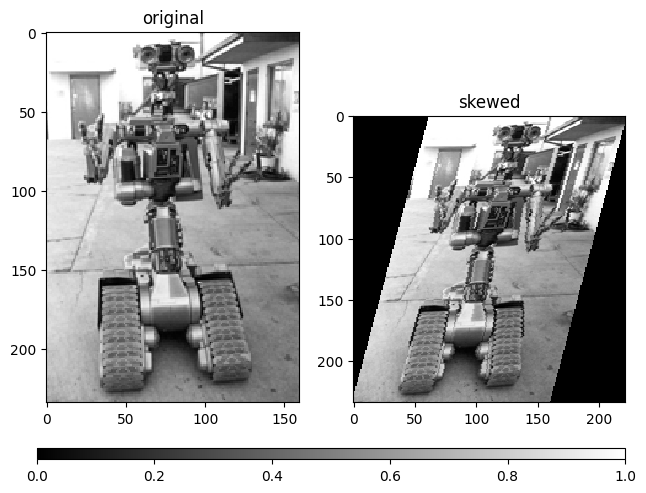

In [26]:
imshow_grid(original=gray, skewed=gray_skw);

### Example: rotation via matrix form

In [27]:
angle = 30. / 180. * np.pi
A_rot = np.array([
    [np.cos(angle), np.sin(angle), 0.,],
    [-np.sin(angle), np.cos(angle), 0.],
    [0., 0., 1.],
])
A_rot, np.linalg.inv(A_rot)

(array([[ 0.866025,  0.5     ,  0.      ],
        [-0.5     ,  0.866025,  0.      ],
        [ 0.      ,  0.      ,  1.      ]]),
 array([[ 0.866025, -0.5     ,  0.      ],
        [ 0.5     ,  0.866025,  0.      ],
        [ 0.      ,  0.      ,  1.      ]]))

In [28]:
gray_rot = warp_affine_inv(gray, A_rot, out_shape=calc_out_shape_affine(gray, A_rot))
gray_rot.shape, gray_rot.dtype

((282, 255), dtype('float64'))

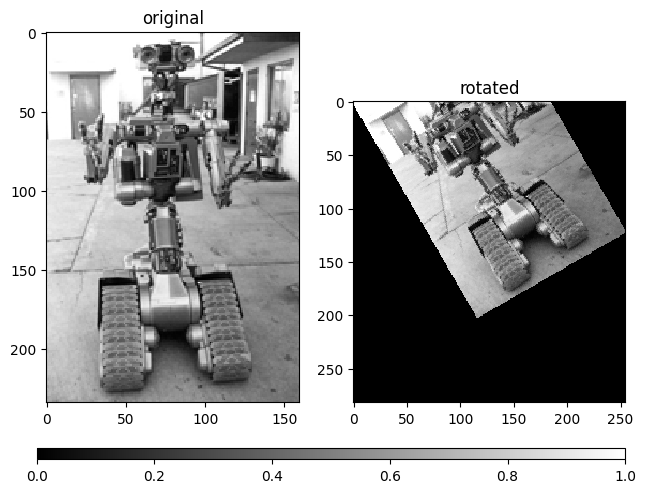

In [29]:
imshow_grid(original=gray, rotated=gray_rot);

## Hierarchy of transformations

- Based on the properties of the $3 \times 3$ *affine* transformation matrix, geometric transformations are usually classified into 3 categories.

**1. Euclidean transformations (isometries)**
- Euclidean transformations represent rotation and translation.
  $$
  \begin{bmatrix}
      x' \\
      y' \\
      1
  \end{bmatrix}
  =
  \begin{bmatrix}
      \pm \cos(\theta) & -\sin(\theta) & t_x \\
      \pm \sin(\theta) &  \cos(\theta) & t_x \\
      0 & 0 & 1
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
      x \\
      y \\
      1
  \end{bmatrix}
  \qquad
  \text{or}
  \qquad
  \bold{x}'
  =
  \begin{bmatrix}
      \bold{R} & \bold{t} \\
      \bold{0}^\top & 1
  \end{bmatrix}
  \cdot
  \bold{x}
  $$
- *Invariants*: Euclidean distance, angle and area.

**2. Similarity transformations**
- Similarity transformations represent combination of scaling, rotation and translation.
  $$
  \begin{bmatrix}
       x' \\
       y' \\
       1
   \end{bmatrix}
   =
   \begin{bmatrix}
       s \cdot \cos(\theta) & -s \cdot \sin(\theta) & t_x \\
       s \cdot \sin(\theta) &  s \cdot \cos(\theta) & t_x \\
       0 & 0 & 1
   \end{bmatrix}
   \cdot
   \begin{bmatrix}
       x \\
       y \\
       1
   \end{bmatrix}
  \qquad
  \text{or}
  \qquad
  \bold{x}'
  =
  \begin{bmatrix}
      s \cdot \bold{R} & \bold{t} \\
      \bold{0}^\top & 1
  \end{bmatrix}
  \cdot
  \bold{x}
  $$
- *Invariants*: angle, ratio of distances.

**3. Affine transformations**
- Affine transformations represent combination of non-isotropic scaling, rotation and translation (and skewing included).
  $$
  \begin{bmatrix}
      x' \\
      y' \\
      1
  \end{bmatrix}
  =
  \begin{bmatrix}
      a_{1,1} & a_{1,2} & t_x \\
      a_{2,1} & a_{2,2} & t_x \\
      0 & 0 & 1
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
      x \\
      y \\
      1
  \end{bmatrix}
  \qquad
  \text{or}
  \qquad
  \bold{x}'
  =
  \begin{bmatrix}
      \bold{A} & \bold{t} \\
      \bold{0}^\top & 1
  \end{bmatrix}
  \cdot
  \bold{x}
  $$
- *Invariants*: parallel lines, ratio of lengths of parallel line segments, ratio of areas.

## Projective transformations (homographies)

- In addition to the affine transformations above, there are also **homographies**, whose last row is not $[0, 0, 1]$.
  $$
  \begin{bmatrix}
      z' \cdot x' \\
      z' \cdot y' \\
      z'
  \end{bmatrix}
  =
  \begin{bmatrix}
      a_{1,1} & a_{1,2} & a_{1,3} \\
      a_{2,1} & a_{2,2} & a_{2,3} \\
      a_{3,1} & a_{3,2} & a_{3,3} \\
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
      x \\
      y \\
      1
  \end{bmatrix}
  \qquad
  \text{or}
  \qquad
  \bold{x}'
  =
  \begin{bmatrix}
      \bold{A} & \bold{t} \\
      \bold{a}^\top & a_{3,3}
  \end{bmatrix}
  \cdot
  \bold{x}
  $$
- Notice that in case of projective transformations, the last element of the transformed vector $z'$ is not in general equal to one.
- In order to compute the final position, we need to normalize $x',y'$ by dividing the vector $\bold{x}'$ by $z'$, i.e.  
  $$
  x' = \frac{a_{1,1} \cdot x + a_{1,2} \cdot y + a_{1,3}}{a_{3,1} \cdot x + a_{3,2} \cdot y + a_{3,3}}
  \qquad
  \text{and}
  \qquad
  y' = \frac{a_{2,1} \cdot x + a_{2,2} \cdot y + a_{2,3}}{a_{3,1} \cdot x + a_{3,2} \cdot y + a_{3,3}}
  $$
- *Invariants*: lines (or any order of a curve), [cross ratio](https://en.wikipedia.org/wiki/Cross-ratio) of lengths on a line.
- Homographies can represent everything affinities can plus **out-of-image-plane rotations (perspective)**.
- They are the most general 2D transformation that maps lines to lines.
- Since we're dividing by $z'$, homographies $\bold{A}$ and $\alpha \cdot \bold{A}$ are equivalent. This means we can choose $\bold{A}$ such that $a_{3,3} = 1$ and thus $\bold{A}$ only has 8 free parameters (degrees of freedom).
- See [scikit-image example](https://scikit-image.org/docs/stable/auto_examples/transform/plot_transform_types.html).

In [ ]:
def compute_tform_span(img: np.ndarray, A: np.ndarray) -> tuple[tuple[int, int], tuple[float, float]]:
    h, w = img.shape[:2]

    # Get image corners and transform them
    X = np.array([0., w, w, 0.])
    Y = np.array([0., 0., h, h])
    XY = np.vstack((X, Y, np.ones(4)))
    XY_ = np.dot(A, XY)
    XY_ = XY_[:2] / XY_[2]  # normalize homogeneous coordinates - this is extra compared to affine case
    dx_, dy_ =  XY_[0, :].min(),  XY_[1, :].min()
    
    # Calculate the new size
    w_ = int(XY_[0, :].max() - XY_[0, :].min())
    h_ = int(XY_[1, :].max() - XY_[1, :].min())
    
    return (h_, w_), (dx_, dy_)

In [31]:
def warp_inv(
    img: np.ndarray,
    A: np.ndarray,
    out_shape: tuple[int, int] | None = None,
    offset: tuple[float, float] = (0.0, 0.0),
) -> np.ndarray:
    # Input shape
    h, w = img.shape[:2]

    # Output shape
    if out_shape is None:
        h_, w_ = h, w
    else:
        h_, w_ = out_shape
    if img.ndim == 2:
        img_ = np.zeros((h_, w_), dtype=img.dtype).squeeze()
    else:
        img_ = np.zeros((h_, w_, img.shape[2]), dtype=img.dtype).squeeze()

    # Invert transformation
    A_inv = np.linalg.inv(A)

    # Helper function to safely get a value gray[y, x]
    def src_img_at(x, y):
        if 0 <= x < w and 0 <= y < h:
            return img[y, x]
        else:
            return 0

    # The main transformation loop
    dx_, dy_ = offset
    for y_ in range(h_):
        for x_ in range(w_):
            x, y, z = np.dot(A_inv, [x_ + dx_, y_ + dy_, 1.0])  # inverse transform
            x, y = x / z, y / z  # normalize homogeneous coordinates - this is extra compared to affine case
            x = int(0.5 + x)  # round
            y = int(0.5 + y)  # round
            img_[y_, x_] = src_img_at(x, y)  # src_img_at defined on line 16 of this function

    return img_

In [32]:
A_hom = np.array([
    [ 0.9, -0.3, 50.],
    [-0.5,  1.0, 30.],
    [-0.002, -0.0015, 1]
])

In [ ]:
gray_hom = warp_inv(gray, A_hom, *compute_tform_span(gray, A_hom))
gray_hom.shape, gray_hom.dtype, gray_hom.min(), gray_hom.max()

((632, 407), dtype('float64'), np.float64(0.0), np.float64(1.0))

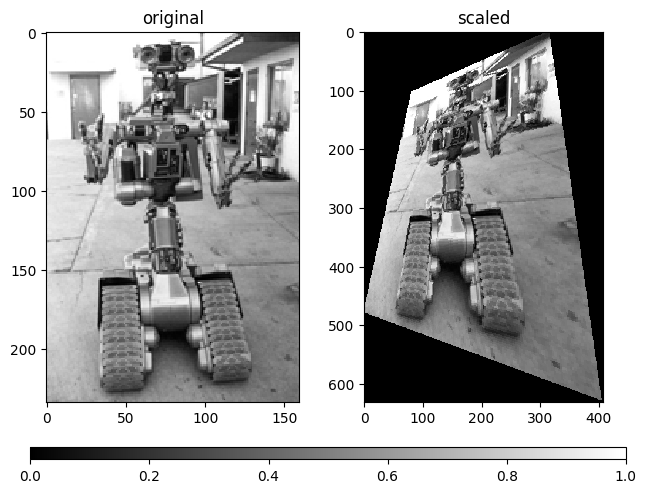

In [34]:
imshow_grid(original=gray, scaled=gray_hom);

In [ ]:
@ipywidgets.interact(
    a11=(-1., 1., 0.01), a12=(-1., 1., 0.01), a13=(-1., 1., 0.01),
    a21=(-1., 1., 0.01), a22=(-1., 1., 0.01), a23=(-1., 1., 0.01),
    a31=(-0.01, 0.01, 0.0001), a32=(-0.01, 0.01, 0.0001), a33=(-1., 1., 0.01),
    readout_format='.3f'
)
def homography_interact(
        a11: float = 1., a12: float = 0., a13: float = 0.,
        a21: float = 0., a22: float = 1., a23: float = 0.,
        a31: float = 0., a32: float = 0., a33: float = 1.,
):
    A_hom = np.array([
        [a11, a12, a13],
        [a21, a22, a23],
        [a31, a32, a33],
    ])
    A_hom /= a33
    warped = warp_inv(gray, A_hom, *compute_tform_span(gray, A_hom))
    plt.imshow(warped, cmap='gray', vmin=0.0, vmax=1.0, interpolation='none')
    # return A_hom

interactive(children=(FloatSlider(value=1.0, description='a11', max=1.0, min=-1.0, step=0.01), FloatSlider(val…

# Brightness interpolation

<figure class="image">
  <img src="../figures/geometric_transformations-forward_inverse_mappings.png" alt="" style="width: 12.8in;"/>
  <figcaption>Source: [Burger22], Fig. 21.14 and 21.15</figcaption>
</figure>

- When computing the inverse mapping, we don't usually obtain integer coordinates $(x, y)$.
- So far, we simply rounded the numbers to the nearest integer.
- But this is just one of many possible ways.
- What if we computed an average of the neighboring pixels instead of picking just one? Or some other statistic?
- In general, we are asking the following question: what is the value of $I(x, y)$ when $\{x, y\} \not\subset \mathbb{Z}^{+}$, i.e. $(x, y)$ are non-integer real numbers?
- In such cases we say we **interpolate** the off-grid values,
  $$
  \tilde{I}(x, y) = \text{interpolate}(I, x, y)
  $$
- See the following figure for 1D example: we have observed (a) and are trying to estimate (b).

<figure class="image">
  <img src="../figures/geometric_transformations-interpolation.png" alt="" style="width: 12.8in;"/>
  <figcaption>Source: [Burger22], Fig. 22.1 and 22.2</figcaption>
</figure>

**Nearest neighbor interpolation**
- In the code above, we made sure we stayed in the discrete image grid by rounding the transformed $(x,y)$ coordinates to the nearest integer.
- Formally, this is called nearest neighbor interpolation, where  
  $$
  \tilde{I}(x, y) = I\left( \left\lfloor x \right\rceil, \left\lfloor y \right\rceil \right)
  $$
  where
  - $\left\lfloor\cdot\right\rceil$ denotes rounding to nearest integer.

**Linear interpolation**
- For visually better looking and smoother non-pixelated results, we may perform a linear interpolation.
- For some 1D function $f$, the interpolation is  
  $$
  \tilde{f}(x) = (1 - d_x) \cdot f(x) + d_x \cdot f(x+1)
  $$
  where
  - $d_x = x - \lfloor x\rfloor$.
- In other words, values inbetween two discrete positions are a weighted average of nearest samples, with the weights being negatively proportional to the distance from either of the two integer positions.
- In 2D, this is generalized to *bilinear interpolation*  
  $$
  \begin{matrix}
  \tilde{I}(x,y) = &   & (1-d_x) & \cdot & (1-d_y) & \cdot & I(x,y) \\
                   & + & d_x     & \cdot & (1-d_y) & \cdot & I(x+1,y) \\
                   & + & (1-d_x) & \cdot & d_y     & \cdot & I(x,y+1) \\
                   & + & d_x     & \cdot & d_y     & \cdot & I(x+1,y+1)
  \end{matrix}
  $$
  where instead of just two pixels, we have to take into account *four* nearest image samples.
- Bilinear interpolation is illustrated in the following figure.

<figure class="image">
  <img src="../figures/geometric_transformations-bilinear_interpolation.png" alt="" style="width: 12.8in;"/>
  <figcaption>Source: [Burger22], Fig. 22.16</figcaption>
</figure>

**Interpolation as convolution**
- Interpolation can be expressed as a convolution of a continuous kernel function $w(x)$ with a discrete image function $f(u)$
  $$
  \tilde{f}(x) = (w * f)(x) = \sum_{u=-\infty}^{+\infty}{w(u - x)\cdot f(u)}
  $$
- It is then the kernel function $w(x)$ that defines which particular interpolation will be performed. For example, *nearest neighbor interpolation* has
  $$
  w_\text{nn}(x) = \begin{cases}
      1 & \text{for} \quad -0.5 \le x \lt 0.5 \\
      0 & \text{otherwise}
  \end{cases}
  $$
- *Linear interpolation* is
  $$
  w_\text{nn}(x) = \begin{cases}
      1 - |x| & \text{for} \quad |x| \lt 1 \\
      0 & \text{otherwise}
  \end{cases}
  $$
- *Cubic interpolation* is
  $$
  w_\text{cub}(x,a) = \begin{cases}
      (-a + 2)\cdot |x|^3 + (a-3)\cdot x^2 + 1 & \text{for} \quad 0 \le |x| \lt 1 \\
      -a \cdot |x|^3 + 5a \cdot x^2 - 8a \cdot |x| + 4a & \text{for} \quad 1 \le |x| \lt 2 \\
      0 & \text{otherwise}
  \end{cases}
  $$

# Geometric transformations in scikit-image

- the `skimage.transform.warp` function will *not* calculate the output dimensions for us $\rightarrow$ we have to provide them
- similarly with transformation matrix $\bold{A}^{-1}$, we have to invert ourselves, the function will not do it for us
- interpolation is specified by the `order` argument
- the function works with RGB images

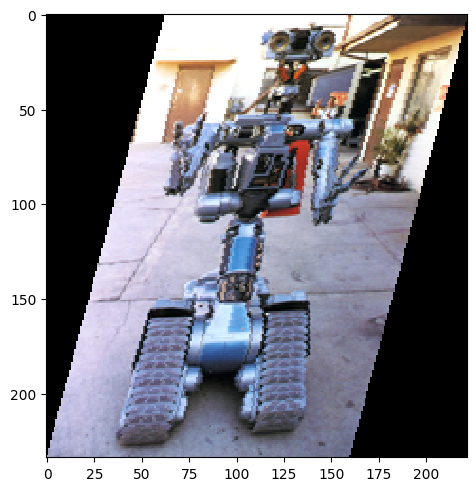

In [36]:
plt.imshow(
    skimage.transform.warp(rgb, np.linalg.inv(A_skw), output_shape=gray_skw.shape, order=0),
    interpolation = 'none'
);

# Geometric transformations in OpenCV

- the function is `warpAffine`
- similarly to scikit-image, we need to calculate the output dimensions manually and pass them into the function
- by default, the function expects *forward* matrix $\bold{A}$, i.e. it will invert automatically

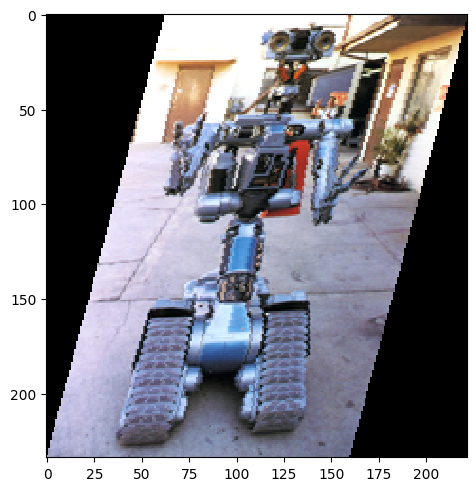

In [37]:
plt.imshow(
    cv.warpAffine(rgb, A_skw[:2, :], (gray_skw.shape[1], gray_skw.shape[0]), flags=cv.INTER_NEAREST), 
    interpolation='none'
);

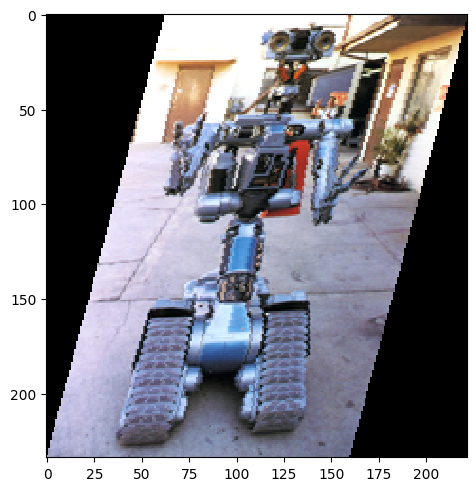

In [38]:
# the same just with the inverse version of the transformation matrix
plt.imshow(
    cv.warpAffine(rgb, np.linalg.inv(A_skw)[:2, :], (gray_skw.shape[1], gray_skw.shape[0]), flags=cv.WARP_INVERSE_MAP),
    interpolation='none'
);

# Image rectification

<figure class="image">
  <img src="../figures/geometric_transformations-recitfication.png" alt="" style="width: 6.4in;"/>
  <figcaption>Source: [Burger22], Fig. 21.17</figcaption>
</figure>

- Imagine that we want to read name and surname from a photo of an ID card, that is not perfectly upright and might even be rotated outside of the image plane.
- In other words, we would like to extract a planar object from an image and register it to a standard coordinate system and size using a geometric transform.
- This is called **image rectification**.
- The problem is, however, that we don't know the values of the homography matrix $\bold{A}$.
- Fortunately, we can estimate it, provided that we know coordinates of object's keypoints in the image, for example the positions the corners of the ID card.

## Affine transformation estimation and image rectification

- Since there are 6 free parameters in an affine trasnform, it is uniquely determined by **3** correspondences (each gives us two constraints, one in x and one in y).

<figure class="image">
  <img src="../figures/geometric_transformations-affine_estimation.png" alt="" style="width: 6.4in;"/>
  <figcaption>Source: [Burger22], Fig. 21.2</figcaption>
</figure>

- Inputs:
  - positions $(x_1', y_1'), \ldots, (x_3', y_3')$ of the corners of the ID card
  - positions $(x_1, y_1), \ldots, (x_3, y_3)$ of the corners of the standard frame (e.g. upright normalized view of the ID card)
- Output:
  - *affine* matrix $\bold{A}$
- To estimate an affine tranform from a set of ≥3 correspondences, we can rewrite the transformation  
  $$
  \begin{bmatrix}
      x_i' \\
      y_i' \\
      1
  \end{bmatrix}
  =
  \begin{bmatrix}
      a_{1,1} & a_{1,2} & a_{1,3} \\
      a_{2,1} & a_{2,2} & a_{2,3} \\
         0    &    0    &    1    \\
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
      x_i \\
      y_i \\
      1
  \end{bmatrix},
  \qquad
  i = 1, \ldots, 4
  $$
  as the following system of linear equations
  $$
  \underbrace{
    \begin{bmatrix}
    x_1 & y_1 &  1  &  0  &  0  &  0  \\
    0  &  0  &  0  & x_1 & y_1 &  1  \\
    x_2 & y_2 &  1  &  0  &  0  &  0  \\
    0  &  0  &  0  & x_2 & y_2 &  1  \\
    x_3 & y_3 &  1  &  0  &  0  &  0  \\
    0  &  0  &  0  & x_3 & y_3 &  1  \\
    \end{bmatrix}
  }_{\bold{M}}
  \cdot
  \underbrace{
    \begin{bmatrix}
    a_{1,1} \\
    a_{1,2} \\
    a_{1,3} \\
    a_{2,1} \\
    a_{2,2} \\
    a_{2,3} \\
    \end{bmatrix}
  }_{\bold{a}}
  =
  \underbrace{
    \begin{bmatrix}
    x_1' \\
    y_1' \\
    x_2' \\
    y_2' \\
    x_3' \\
    y_3' \\
    \end{bmatrix}
  }_{\bold{b}}
  $$  
  and then solve for the unknown vector of coefficents $\bold{a}$.

In [39]:
def estimate_affinity(
    src_pts: np.ndarray,  # (N, 2)
    dst_pts: np.ndarray,  # (N, 2)
) -> np.ndarray:
    """
    Estimate the affine transformation matrix from point correspondences.
    Needs at least N >= 3 correspondences.

    Args:
        src_pts: Source points of shape (N, 2).
        dst_pts: Destination points of shape (N, 2).

    Returns:
        Affine transformation matrix of shape (3, 3).
    """
    # Construct the linear system
    M = []
    b = []
    for (x, y), (x_, y_) in zip(src_pts, dst_pts):
        M.append([x, y, 1, 0, 0, 0])
        M.append([0, 0, 0, x, y, 1])
        b.append(x_)
        b.append(y_)
    M = np.array(M)
    b = np.array(b)

    # Solve for the affine transformation parameters using least squares
    a, _, _, _ = np.linalg.lstsq(M, b, rcond=None)
    return np.vstack((a.reshape(2, 3), [0, 0, 1]))  # Convert to homogeneous matrix

In [40]:
rgb = skimage.io.imread('../data/CA10_01.jpg')
rgb.dtype, rgb.shape, rgb.min(), rgb.max()

(dtype('uint8'), (1920, 1080, 3), np.uint8(0), np.uint8(255))

In [41]:
# We will define corners of the region in the original image in homogenous form as "source" points
src_xy = np.array(
    [
        (267, 644),
        (941, 887),
        (784, 1310),
        (96, 1047)
    ],
    dtype=np.float32
)
src_xy

array([[ 267.,  644.],
       [ 941.,  887.],
       [ 784., 1310.],
       [  96., 1047.]], dtype=float32)

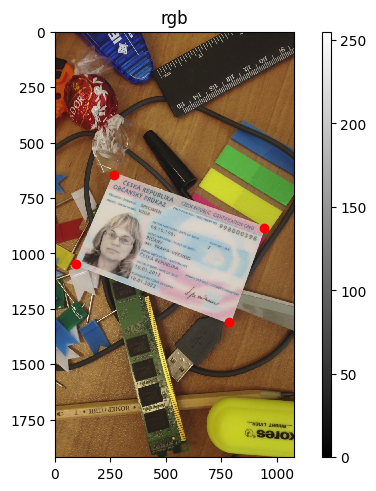

In [42]:
imshow_grid(rgb=rgb);
plt.plot(src_xy[:, 0], src_xy[:, 1], 'o', color=(1, 0, 0));

In [43]:
# Select target size (height x width)
dst_shape = 420, 669

In [44]:
# Target points will be corners of the resulting image
dst_xy = np.array(
    [
        (0, 0),
        (dst_shape[1], 0),
        (dst_shape[1], dst_shape[0]),
        (0, dst_shape[0])
    ],
    dtype=np.float32
)
dst_xy

array([[  0.,   0.],
       [669.,   0.],
       [669., 420.],
       [  0., 420.]], dtype=float32)

In [45]:
A_aff = estimate_affinity(src_xy, dst_xy)
A_aff, np.linalg.inv(A_aff)  # affine transformation matrix

(array([[   0.856031,    0.33957 , -442.410251],
        [  -0.329276,    0.885948, -479.259289],
        [   0.      ,    0.      ,    1.      ]]),
 array([[  1.018084,  -0.390216, 263.396218],
        [  0.378386,   0.983705, 638.851741],
        [  0.      ,   0.      ,   1.      ]]))

In [46]:
roi_aff = warp_affine_inv(rgb, A_aff, out_shape=dst_shape)
roi_aff.shape, roi_aff.dtype, roi_aff.min(), roi_aff.max()

((420, 669, 3), dtype('uint8'), np.uint8(29), np.uint8(223))

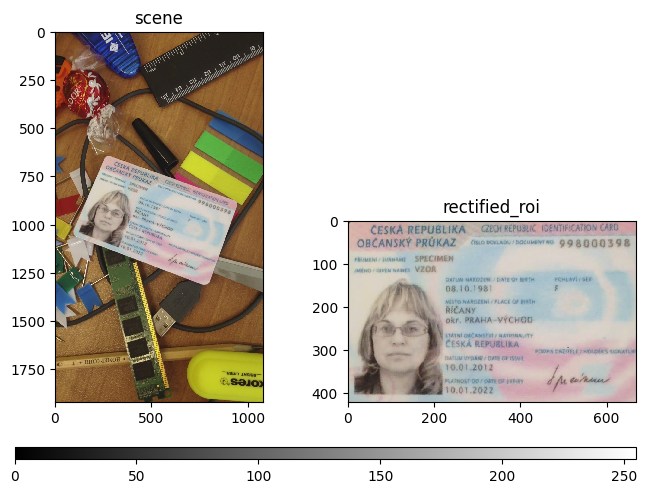

In [47]:
imshow_grid(scene=rgb, rectified_roi=roi_aff);

## Projective transformation estimation

- Homographies have 8 free parameters, therefore are uniquely determined by **4** correspondences.

<figure class="image">
  <img src="../figures/geometric_transformations-homography_estimation.png" alt="" style="width: 6.4in;"/>
  <figcaption>Source: [Burger22], Fig. 21.3</figcaption>
</figure>


- Inputs:
  - positions $(x_1', y_1'), \ldots, (x_4', y_4')$ of the corners of the ID card
  - positions $(x_1, y_1), \ldots, (x_4, y_4)$ of the corners of the standard frame (e.g. upright normalized view of the ID card)
- Output:
  - homography matrix $\bold{A}$
- To estimate a projective tranform from a set of ≥4 correspondences, we can rewrite the transformation  
  $$
  \begin{bmatrix}
      z_i' \cdot x_i' \\
      z_i' \cdot y_i' \\
      z_i'
  \end{bmatrix}
  =
  \begin{bmatrix}
      a_{1,1} & a_{1,2} & a_{1,3} \\
      a_{2,1} & a_{2,2} & a_{2,3} \\
      a_{3,1} & a_{3,2} & 1 \\
  \end{bmatrix}
  \cdot
  \begin{bmatrix}
      x_i \\
      y_i \\
      1
  \end{bmatrix},
  \qquad
  i = 1, \ldots, 4
  $$
  as  
  $$
  x' \cdot (a_{3,1} \cdot x + a_{3,2} \cdot y + 1) = a_{1,1} \cdot x + a_{1,2} \cdot y + a_{1,3} \\
  y' \cdot (a_{3,1} \cdot x + a_{3,2} \cdot y + 1) = a_{2,1} \cdot x + a_{2,2} \cdot y + a_{2,3} \\
  $$  
  then by expanding the left side as  
  $$
  a_{3,1} \cdot x \cdot x' + a_{3,2} \cdot y \cdot x' + x' = a_{1,1} \cdot x + a_{1,2} \cdot y + a_{1,3} \\
  a_{3,1} \cdot x \cdot y' + a_{3,2} \cdot y \cdot y' + y' = a_{2,1} \cdot x + a_{2,2} \cdot y + a_{2,3} \\
  $$  
  and finally by rearranging the terms as the following system of linear equations  
  $$
  \underbrace{
    \begin{bmatrix}
    x_1 & y_1 &  1  &  0  &  0  &  0  & -x_1\cdot x_1' & -y_1\cdot x_1' \\
    0  &  0  &  0  & x_1 & y_1 &  1  & -x_1\cdot y_1' & -y_1\cdot y_1' \\
    x_2 & y_2 &  1  &  0  &  0  &  0  & -x_2\cdot x_2' & -y_2\cdot x_2' \\
    0  &  0  &  0  & x_2 & y_2 &  1  & -x_2\cdot y_2' & -y_2\cdot y_2' \\
    x_3 & y_3 &  1  &  0  &  0  &  0  & -x_3\cdot x_3' & -y_3\cdot x_3' \\
    0  &  0  &  0  & x_3 & y_3 &  1  & -x_3\cdot y_3' & -y_3\cdot y_3' \\
    x_4 & y_4 &  1  &  0  &  0  &  0  & -x_4\cdot x_4' & -y_4\cdot x_4' \\
    0  &  0  &  0  & x_4 & y_4 &  1  & -x_4\cdot y_4' & -y_4\cdot y_4'
    \end{bmatrix}
  }_{\bold{M}}
  \cdot
  \underbrace{
    \begin{bmatrix}
    a_{1,1} \\
    a_{1,2} \\
    a_{1,3} \\
    a_{2,1} \\
    a_{2,2} \\
    a_{2,3} \\
    a_{3,1} \\
    a_{3,2}
    \end{bmatrix}
  }_{\bold{a}}
  =
  \underbrace{
    \begin{bmatrix}
    x_1' \\
    y_1' \\
    x_2' \\
    y_2' \\
    x_3' \\
    y_3' \\
    x_4' \\
    y_4' \\
    \end{bmatrix}
  }_{\bold{b}}
  $$  
  and then solve for the unknown vector of coefficents $\bold{a}$.

In [48]:
def estimate_homography(
    src_pts: np.ndarray,  # (N, 2)
    dst_pts: np.ndarray,  # (N, 2)
) -> np.ndarray:
    """
    Estimate the homography matrix from point correspondences.
    Needs at least N >= 4 correspondences.

    Args:
        src_pts: Source points of shape (N, 2).
        dst_pts: Destination points of shape (N, 2).

    Returns:
        Homography matrix of shape (3, 3).
    """
    # Construct the linear system
    M = []
    b = []
    for (x, y), (x_, y_) in zip(src_pts, dst_pts):
        M.append([x, y, 1, 0, 0, 0, -x * x_, -y * x_])
        M.append([0, 0, 0, x, y, 1, -x * y_, -y * y_])
        b.append(x_)
        b.append(y_)

    # Solve for the homography parameters using least squares
    a, _, _, _ = np.linalg.lstsq(M, b, rcond=None)
    return np.append(a, 1.0).reshape(3, 3)

In [49]:
A_hom = estimate_homography(src_xy, dst_xy)
A_hom, np.linalg.inv(A_hom)  # homography transformation matrix

(array([[   0.939269,    0.398549, -507.450157],
        [  -0.354444,    0.983107, -538.484727],
        [   0.00002 ,    0.000082,    1.      ]]),
 array([[  0.911955,  -0.390727, 252.371169],
        [  0.305322,   0.842698, 608.71548 ],
        [ -0.000043,  -0.000061,   0.94521 ]]))

In [50]:
roi_hom = warp_inv(rgb, A_hom, out_shape=dst_shape)
roi_hom.shape, roi_hom.dtype, roi_hom.min(), roi_hom.max()

((420, 669, 3), dtype('uint8'), np.uint8(29), np.uint8(223))

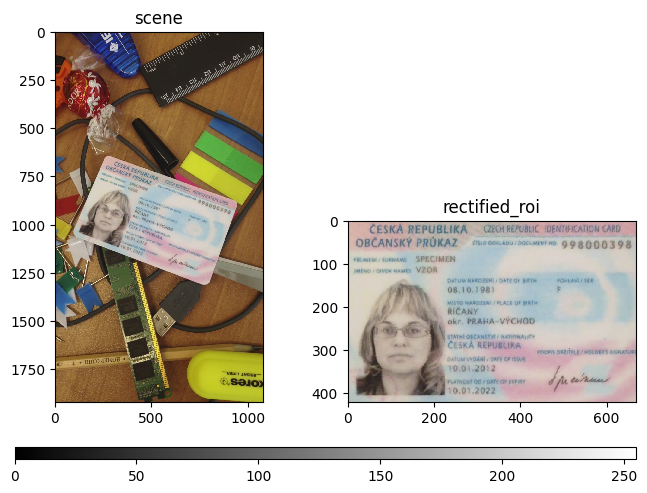

In [51]:
imshow_grid(scene=rgb, rectified_roi=roi_hom);

A_aff
 [[   0.856031    0.33957  -442.410251]
 [  -0.329276    0.885948 -479.259289]
 [   0.          0.          1.      ]]
A_hom
 [[   0.939269    0.398549 -507.450157]
 [  -0.354444    0.983107 -538.484727]
 [   0.00002     0.000082    1.      ]]


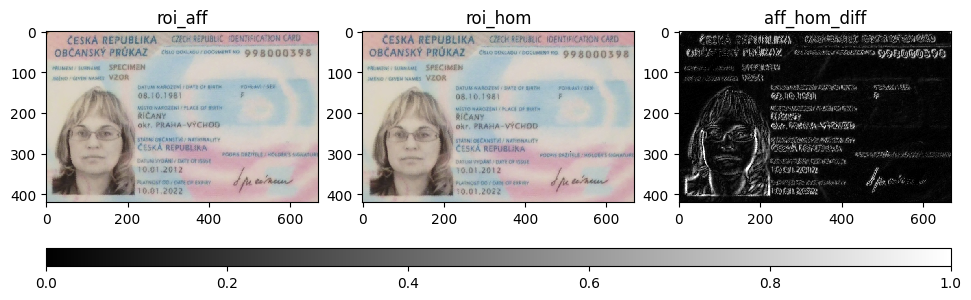

In [52]:
print('A_aff\n', A_aff)
print('A_hom\n', A_hom)

imshow_grid(roi_aff=roi_aff, roi_hom=roi_hom, aff_hom_diff=np.sum(np.abs(roi_aff / 255 - roi_hom / 255), axis=2));

## Estimation in scikit-image

In [53]:
tform = skimage.transform.estimate_transform('projective', src_xy, dst_xy)  # can be 'affine' as well
tform.params  # homography matrix

array([[   0.939269,    0.398549, -507.450157],
       [  -0.354444,    0.983107, -538.484727],
       [   0.00002 ,    0.000082,    1.      ]])

In [54]:
roi = skimage.transform.warp(rgb, np.linalg.inv(tform.params), output_shape=dst_shape)
roi.shape, roi.dtype, roi.min(), roi.max()

((420, 669, 3),
 dtype('float64'),
 np.float64(0.11764705882352941),
 np.float64(0.8733352713180841))

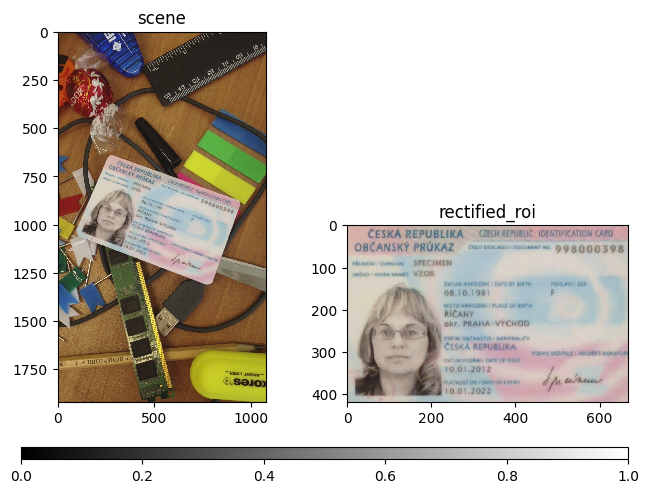

In [55]:
imshow_grid(scene=rgb, rectified_roi=roi);